# 67 - SigLIP 2 Large ONNX 評価（Python vs JS 総合比較）

## 概要
SigLIP 2 **Large** (`google/siglip2-large-patch16-256`) の ONNX モデルを
Transformers.js (Node.js) で実行し、Python (PyTorch) との互換性を評価する。

## 背景
- Notebook 63: SigLIP 2 Large は **JA MRR 1.000**（全モデル中最強）を Python で達成
- Notebook 64-65: SigLIP 2 Base の ONNX は Python-JS テキスト互換性 1.000 を確認
- 課題: Base の q8 量子化が破損（0.750）。Large でも同様か？

## 評価項目
1. **画像埋め込み: Python vs JS コサイン類似度**（fp32, fp16, q8, q4）
2. **テキスト埋め込み: Python vs JS コサイン類似度**（EN + JA）
3. **テキスト→画像検索 MRR: Python vs JS**（18 クエリ）
4. **fp16 の詳細評価**（速度・品質トレードオフ）

## モデル情報
| 項目 | 値 |
|------|-----|
| Python | `google/siglip2-large-patch16-256` |
| ONNX | `onnx-community/siglip2-large-patch16-256-ONNX` |
| 次元 | 1024 |
| 解像度 | 256x256 |

In [1]:
import json
import os
import subprocess
import tempfile
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance

from image_vector_poc import SigLIP2Embedder

## 1. 環境設定

In [2]:
# nvm の Node.js パスを追加
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js version: {result.stdout.strip()}")

# パス設定
DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../js")
PYTHON_MODEL = "google/siglip2-large-patch16-256"
JS_MODEL = "onnx-community/siglip2-large-patch16-256-ONNX"
EMBEDDING_DIM = 1024

Node.js version: v24.13.1


## 2. 画像カタログの読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)
catalog_df = conn.execute("""
    SELECT id, file_path, category FROM image_catalog ORDER BY id
""").fetchdf()
conn.close()

print(f"Images: {len(catalog_df)}")
print(f"Categories: {catalog_df['category'].nunique()}")

Images: 378
Categories: 6


## 3. Python 画像埋め込み生成

In [4]:
from PIL import Image
import time

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device="cuda")
print(f"Model: {embedder.model_name}")
print(f"Embedding dim: {embedder.embedding_dim}")

# バッチ処理で画像埋め込みを生成
BATCH_SIZE = 32
all_images = []
valid_ids = []

for _, row in catalog_df.iterrows():
    try:
        img = Image.open(row["file_path"]).convert("RGB")
        all_images.append(img)
        valid_ids.append(row["id"])
    except Exception as e:
        print(f"Error loading {row['file_path']}: {e}")

print(f"Loaded {len(all_images)} images")

start_time = time.time()
all_embeddings = []
for i in range(0, len(all_images), BATCH_SIZE):
    batch = all_images[i:i+BATCH_SIZE]
    batch_emb = embedder.embed_images(batch)
    all_embeddings.append(batch_emb)

py_embeddings_array = np.concatenate(all_embeddings, axis=0)
elapsed = time.time() - start_time

print(f"Python embeddings shape: {py_embeddings_array.shape}")
print(f"Processing time: {elapsed:.1f}s ({len(all_images)/elapsed:.1f} img/s)")

# ID → 埋め込み辞書
py_embeddings = {vid: py_embeddings_array[i] for i, vid in enumerate(valid_ids)}

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model: google/siglip2-large-patch16-256
Embedding dim: 1024


Loaded 378 images


Python embeddings shape: (378, 1024)
Processing time: 55.6s (6.8 img/s)


## 4. JS 画像埋め込み生成（4 dtype）

In [5]:
# JS スクリプト用の画像リスト JSON
image_list = [{"id": row["id"], "file_path": row["file_path"]} for _, row in catalog_df.iterrows()]
image_list_path = Path(tempfile.mktemp(suffix=".json"))
with open(image_list_path, "w") as f:
    json.dump(image_list, f)

print(f"Image list: {len(image_list)} images")

dtypes = ["fp32", "fp16", "q8", "q4"]
js_results = {}

for dtype in dtypes:
    print(f"\n{'='*50}")
    print(f"Running JS embedding with dtype={dtype}...")
    print(f"{'='*50}")
    
    output_path = Path(tempfile.mktemp(suffix=f"_large_{dtype}.json"))
    
    cmd = [
        "node", str(JS_DIR / "embed_images_siglip2.mjs"),
        "--image-list", str(image_list_path),
        "--output", str(output_path),
        "--dtype", dtype,
        "--model", JS_MODEL,
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
    print(result.stderr[-500:] if len(result.stderr) > 500 else result.stderr)
    
    if result.returncode != 0:
        print(f"ERROR: JS process failed with return code {result.returncode}")
        continue
    
    with open(output_path) as f:
        js_output = json.load(f)
    
    js_results[dtype] = js_output
    print(f"  Model: {js_output['model']}")
    print(f"  Count: {js_output['count']}")
    print(f"  Time: {js_output['processing_time_seconds']}s")
    
    output_path.unlink(missing_ok=True)

image_list_path.unlink(missing_ok=True)
print(f"\n\nCompleted dtypes: {list(js_results.keys())}")

Image list: 378 images

Running JS embedding with dtype=fp32...


 [280/378] 155.9s elapsed (1.8 img/s)
  [290/378] 161.0s elapsed (1.8 img/s)
  [300/378] 165.6s elapsed (1.8 img/s)
  [310/378] 170.6s elapsed (1.8 img/s)
  [320/378] 176.9s elapsed (1.8 img/s)
  [330/378] 182.5s elapsed (1.8 img/s)
  [340/378] 187.8s elapsed (1.8 img/s)
  [350/378] 192.7s elapsed (1.8 img/s)
  [360/378] 198.8s elapsed (1.8 img/s)
  [370/378] 204.7s elapsed (1.8 img/s)
  [378/378] 209.6s elapsed (1.8 img/s)
Done. 378 embeddings saved to /tmp/tmpkvt2frtq_large_fp32.json (209.6s)

  Model: onnx-community/siglip2-large-patch16-256-ONNX
  Count: 378
  Time: 209.6s

Running JS embedding with dtype=fp16...


 [280/378] 218.4s elapsed (1.3 img/s)
  [290/378] 226.5s elapsed (1.3 img/s)
  [300/378] 234.3s elapsed (1.3 img/s)
  [310/378] 242.1s elapsed (1.3 img/s)
  [320/378] 249.5s elapsed (1.3 img/s)
  [330/378] 257.6s elapsed (1.3 img/s)
  [340/378] 265.3s elapsed (1.3 img/s)
  [350/378] 272.1s elapsed (1.3 img/s)
  [360/378] 279.7s elapsed (1.3 img/s)
  [370/378] 287.9s elapsed (1.3 img/s)
  [378/378] 293.8s elapsed (1.3 img/s)
Done. 378 embeddings saved to /tmp/tmphgiz_lyp_large_fp16.json (293.8s)

  Model: onnx-community/siglip2-large-patch16-256-ONNX
  Count: 378
  Time: 293.8s

Running JS embedding with dtype=q8...



  [280/378] 126.5s elapsed (2.2 img/s)
  [290/378] 130.6s elapsed (2.2 img/s)
  [300/378] 134.2s elapsed (2.2 img/s)
  [310/378] 138.6s elapsed (2.2 img/s)
  [320/378] 142.8s elapsed (2.2 img/s)
  [330/378] 147.5s elapsed (2.2 img/s)
  [340/378] 152.1s elapsed (2.2 img/s)
  [350/378] 156.6s elapsed (2.2 img/s)
  [360/378] 161.7s elapsed (2.2 img/s)
  [370/378] 166.4s elapsed (2.2 img/s)
  [378/378] 170.1s elapsed (2.2 img/s)
Done. 378 embeddings saved to /tmp/tmpybj7fddc_large_q8.json (170.1s)

  Model: onnx-community/siglip2-large-patch16-256-ONNX
  Count: 378
  Time: 170.1s

Running JS embedding with dtype=q4...



  [280/378] 156.8s elapsed (1.8 img/s)
  [290/378] 162.2s elapsed (1.8 img/s)
  [300/378] 167.2s elapsed (1.8 img/s)
  [310/378] 172.5s elapsed (1.8 img/s)
  [320/378] 178.1s elapsed (1.8 img/s)
  [330/378] 183.5s elapsed (1.8 img/s)
  [340/378] 189.5s elapsed (1.8 img/s)
  [350/378] 194.6s elapsed (1.8 img/s)
  [360/378] 201.0s elapsed (1.8 img/s)
  [370/378] 206.8s elapsed (1.8 img/s)
  [378/378] 211.4s elapsed (1.8 img/s)
Done. 378 embeddings saved to /tmp/tmp71bi34xg_large_q4.json (211.4s)

  Model: onnx-community/siglip2-large-patch16-256-ONNX
  Count: 378
  Time: 211.4s


Completed dtypes: ['fp32', 'fp16', 'q8', 'q4']


## 5. 画像埋め込み: Python vs JS コサイン類似度

In [6]:
comparison_results = {}

for dtype, js_output in js_results.items():
    js_embeddings = {item['id']: np.array(item['embedding'], dtype=np.float32)
                     for item in js_output['embeddings']}
    
    similarities = []
    for image_id in py_embeddings:
        if image_id in js_embeddings:
            py_emb = py_embeddings[image_id]
            js_emb = js_embeddings[image_id]
            if np.any(js_emb != 0):  # skip zero placeholders
                sim = 1.0 - cosine_distance(py_emb, js_emb)
                similarities.append(sim)
    
    sims = np.array(similarities)
    comparison_results[dtype] = {
        'mean': float(sims.mean()),
        'std': float(sims.std()),
        'min': float(sims.min()),
        'max': float(sims.max()),
        'median': float(np.median(sims)),
        'count': len(sims),
        'processing_time': js_output['processing_time_seconds'],
    }

print("=" * 80)
print("Python vs JS 画像埋め込みコサイン類似度 (SigLIP 2 Large)")
print("=" * 80)

print(f"\n{'dtype':<8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8} {'Time(s)':>10}")
print("-" * 62)
for dtype, r in comparison_results.items():
    print(f"{dtype:<8} {r['mean']:>8.4f} {r['std']:>8.4f} {r['min']:>8.4f} {r['max']:>8.4f} {r['median']:>8.4f} {r['processing_time']:>10.1f}")

print(f"\n--- SigLIP 2 Base の結果（参考）---")
print(f"Base fp32: mean=0.924, fp16: 0.924, q8: 0.750(破損), q4: 0.902")
print(f"--- 他モデルの参考値 ---")
print(f"SigLIP 1 fp32: mean=0.906")
print(f"CLIP-L fp32: mean=0.872")

Python vs JS 画像埋め込みコサイン類似度 (SigLIP 2 Large)

dtype        Mean      Std      Min      Max   Median    Time(s)
--------------------------------------------------------------
fp32       0.9115   0.0307   0.7953   0.9955   0.9150      209.6
fp16       0.9115   0.0307   0.7954   0.9955   0.9150      293.8
q8         0.8559   0.0467   0.7067   0.9657   0.8623      170.1
q4         0.9016   0.0315   0.7773   0.9868   0.9058      211.4

--- SigLIP 2 Base の結果（参考）---
Base fp32: mean=0.924, fp16: 0.924, q8: 0.750(破損), q4: 0.902
--- 他モデルの参考値 ---
SigLIP 1 fp32: mean=0.906
CLIP-L fp32: mean=0.872


## 6. 量子化の内部比較（JS fp32 vs 各 dtype）

In [7]:
if 'fp32' in js_results and len(js_results) >= 2:
    print("=" * 60)
    print("量子化の影響: fp32 vs 各 dtype（JS 内の比較）")
    print("=" * 60)
    
    fp32_embs = {item['id']: np.array(item['embedding'], dtype=np.float32)
                 for item in js_results['fp32']['embeddings']}
    
    quant_comparison = {}
    for dtype in ['fp16', 'q8', 'q4']:
        if dtype not in js_results:
            continue
        other_embs = {item['id']: np.array(item['embedding'], dtype=np.float32)
                     for item in js_results[dtype]['embeddings']}
        
        sims = []
        for img_id in fp32_embs:
            if img_id in other_embs and np.any(other_embs[img_id] != 0):
                sim = 1.0 - cosine_distance(fp32_embs[img_id], other_embs[img_id])
                sims.append(sim)
        
        sims = np.array(sims)
        quant_comparison[dtype] = {'mean': float(sims.mean()), 'std': float(sims.std()), 'min': float(sims.min())}
        print(f"  fp32 vs {dtype}: mean={sims.mean():.6f}, std={sims.std():.6f}, min={sims.min():.6f}")
    
    print(f"\n--- Base の参考値 ---")
    print(f"  fp32 vs fp16: 1.000000")
    print(f"  fp32 vs q8:   0.772013")
    print(f"  fp32 vs q4:   0.964818")
else:
    print("Not enough dtype results for comparison.")
    quant_comparison = {}

量子化の影響: fp32 vs 各 dtype（JS 内の比較）


  fp32 vs fp16: mean=0.999997, std=0.000009, min=0.999857
  fp32 vs q8: mean=0.918728, std=0.037919, min=0.766074
  fp32 vs q4: mean=0.979137, std=0.008852, min=0.933402

--- Base の参考値 ---
  fp32 vs fp16: 1.000000
  fp32 vs q8:   0.772013
  fp32 vs q4:   0.964818


## 7. テキスト埋め込み: Python vs JS コサイン類似度

In [8]:
# 18 クエリのテキスト
all_texts = [
    "a park with trees and nature",
    "village park with greenery",
    "night cityscape Tokyo",
    "city lights at night",
    "Python conference presentation",
    "conference hall with audience",
    "speaker giving a talk",
    "portrait photo of a person",
    "outdoor nature scene",
    "urban night photography",
    "tech conference event",
    "people at an event",
    "公園の自然風景",
    "東京の夜景",
    "カンファレンスの講演",
    "人物の写真",
    "緑の木々",
    "夜の街",
]

# Python テキスト埋め込み
py_text_embeddings = embedder.embed_texts(all_texts)
print(f"Python text embeddings shape: {py_text_embeddings.shape}")

Python text embeddings shape: (18, 1024)


In [9]:
# JS テキスト埋め込み (fp32)
texts_path = Path(tempfile.mktemp(suffix=".json"))
output_path = Path(tempfile.mktemp(suffix=".json"))

with open(texts_path, "w") as f:
    json.dump(all_texts, f, ensure_ascii=False)

cmd = [
    "node", str(JS_DIR / "embed_texts_siglip2.mjs"),
    "--texts", str(texts_path),
    "--output", str(output_path),
    "--dtype", "fp32",
    "--model", JS_MODEL,
]

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print("JS stderr:")
print(result.stderr)

js_text_output_fp32 = None
if result.returncode == 0:
    with open(output_path) as f:
        js_text_output_fp32 = json.load(f)
    print(f"JS text embeddings (fp32): {js_text_output_fp32['count']}")
else:
    print(f"ERROR: JS process failed")

texts_path.unlink(missing_ok=True)
output_path.unlink(missing_ok=True)

JS stderr:
Model: onnx-community/siglip2-large-patch16-256-ONNX
dtype: fp32
Texts to process: 18
Loading model and tokenizer...
Model loaded in 206.8s
Tokenizer type: GemmaTokenizer
  [10/18] 0.9s elapsed
  [18/18] 1.6s elapsed
Done. 18 text embeddings saved to /tmp/tmpqrkmcben.json (1.6s)

JS text embeddings (fp32): 18


In [10]:
# JS テキスト埋め込み (fp16)
texts_path = Path(tempfile.mktemp(suffix=".json"))
output_path = Path(tempfile.mktemp(suffix=".json"))

with open(texts_path, "w") as f:
    json.dump(all_texts, f, ensure_ascii=False)

cmd = [
    "node", str(JS_DIR / "embed_texts_siglip2.mjs"),
    "--texts", str(texts_path),
    "--output", str(output_path),
    "--dtype", "fp16",
    "--model", JS_MODEL,
]

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print("JS stderr:")
print(result.stderr)

js_text_output_fp16 = None
if result.returncode == 0:
    with open(output_path) as f:
        js_text_output_fp16 = json.load(f)
    print(f"JS text embeddings (fp16): {js_text_output_fp16['count']}")
else:
    print(f"ERROR: JS process failed")

texts_path.unlink(missing_ok=True)
output_path.unlink(missing_ok=True)

JS stderr:
Model: onnx-community/siglip2-large-patch16-256-ONNX
dtype: fp16
Texts to process: 18
Loading model and tokenizer...
Model loaded in 104.9s
Tokenizer type: GemmaTokenizer
  [10/18] 2.8s elapsed
  [18/18] 4.5s elapsed
Done. 18 text embeddings saved to /tmp/tmpzc30f8bh.json (4.5s)

JS text embeddings (fp16): 18


In [11]:
# Python vs JS テキスト埋め込みのコサイン類似度
print("=" * 80)
print("Python vs JS テキスト埋め込み コサイン類似度 (Large)")
print("=" * 80)

text_sims_results = {}

for label, js_output in [("fp32", js_text_output_fp32), ("fp16", js_text_output_fp16)]:
    if js_output is None:
        continue
    
    text_sims = []
    print(f"\n--- {label} ---")
    for i, (text, js_item) in enumerate(zip(all_texts, js_output['embeddings'])):
        py_emb = py_text_embeddings[i]
        js_emb = np.array(js_item['embedding'], dtype=np.float32)
        sim = 1.0 - cosine_distance(py_emb, js_emb)
        
        is_ja = any(ord(c) > 0x3000 for c in text)
        lang = "JA" if is_ja else "EN"
        text_sims.append({'text': text, 'lang': lang, 'cosine_sim': sim})
        print(f"  [{lang}] {text[:40]:40s} | cos_sim = {sim:.6f}")
    
    text_sims_df = pd.DataFrame(text_sims)
    en_mean = text_sims_df[text_sims_df['lang']=='EN']['cosine_sim'].mean()
    ja_mean = text_sims_df[text_sims_df['lang']=='JA']['cosine_sim'].mean()
    print(f"\n  Summary: EN={en_mean:.6f}, JA={ja_mean:.6f}")
    text_sims_results[label] = {'en': en_mean, 'ja': ja_mean, 'all': text_sims_df['cosine_sim'].mean()}

print(f"\n--- Base の参考値 ---")
print(f"  SigLIP 2 Base: EN=1.000, JA=1.000")
print(f"  SigLIP 1:      EN=1.000, JA=0.656")

Python vs JS テキスト埋め込み コサイン類似度 (Large)

--- fp32 ---
  [EN] a park with trees and nature             | cos_sim = 1.000000
  [EN] village park with greenery               | cos_sim = 1.000000
  [EN] night cityscape Tokyo                    | cos_sim = 1.000000
  [EN] city lights at night                     | cos_sim = 1.000000
  [EN] Python conference presentation           | cos_sim = 1.000000
  [EN] conference hall with audience            | cos_sim = 1.000000
  [EN] speaker giving a talk                    | cos_sim = 1.000000
  [EN] portrait photo of a person               | cos_sim = 1.000000
  [EN] outdoor nature scene                     | cos_sim = 1.000000
  [EN] urban night photography                  | cos_sim = 1.000000
  [EN] tech conference event                    | cos_sim = 1.000000
  [EN] people at an event                       | cos_sim = 1.000000
  [JA] 公園の自然風景                                  | cos_sim = 1.000000
  [JA] 東京の夜景                                    | c

## 8. テキスト→画像検索 MRR 比較

In [12]:
# テストクエリ定義
test_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "lang": "en"},
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
]

# 画像埋め込みを正規化
norms = np.linalg.norm(py_embeddings_array, axis=1, keepdims=True)
image_embeddings_norm = py_embeddings_array / np.clip(norms, 1e-8, None)
categories = catalog_df['category'].tolist()


def compute_search_mrr(text_embeddings, image_embeddings_norm, categories, test_queries):
    results = []
    for i, q in enumerate(test_queries):
        text_emb = text_embeddings[i]
        text_emb = text_emb / np.linalg.norm(text_emb)
        
        similarities = np.dot(image_embeddings_norm, text_emb)
        top_indices = np.argsort(similarities)[::-1][:20]
        result_cats = [categories[idx] for idx in top_indices]
        is_relevant = [cat in q['expected_categories'] for cat in result_cats]
        
        mrr = 0.0
        for j, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (j + 1)
                break
        
        p_at_1 = sum(is_relevant[:1])
        results.append({'query': q['query'], 'lang': q['lang'], 'MRR': mrr, 'P@1': p_at_1})
    
    return pd.DataFrame(results)

print(f"Image embeddings: {image_embeddings_norm.shape}")

Image embeddings: (378, 1024)


In [13]:
# Python テキスト検索
py_search_df = compute_search_mrr(py_text_embeddings, image_embeddings_norm, categories, test_queries)

print("Python テキスト検索結果:")
for _, row in py_search_df.iterrows():
    print(f"  [{row['lang'].upper()}] {row['query'][:35]:35s} | MRR={row['MRR']:.2f} | P@1={row['P@1']:.0f}")

print(f"\n全体 MRR: {py_search_df['MRR'].mean():.4f}")
print(f"EN MRR:   {py_search_df[py_search_df['lang']=='en']['MRR'].mean():.4f}")
print(f"JA MRR:   {py_search_df[py_search_df['lang']=='ja']['MRR'].mean():.4f}")

Python テキスト検索結果:
  [EN] a park with trees and nature        | MRR=0.50 | P@1=0
  [EN] village park with greenery          | MRR=0.20 | P@1=0
  [EN] night cityscape Tokyo               | MRR=1.00 | P@1=1
  [EN] city lights at night                | MRR=1.00 | P@1=1
  [EN] Python conference presentation      | MRR=1.00 | P@1=1
  [EN] conference hall with audience       | MRR=1.00 | P@1=1
  [EN] speaker giving a talk               | MRR=1.00 | P@1=1
  [EN] portrait photo of a person          | MRR=1.00 | P@1=1
  [EN] outdoor nature scene                | MRR=1.00 | P@1=1
  [EN] urban night photography             | MRR=1.00 | P@1=1
  [EN] tech conference event               | MRR=1.00 | P@1=1
  [EN] people at an event                  | MRR=1.00 | P@1=1
  [JA] 公園の自然風景                             | MRR=1.00 | P@1=1
  [JA] 東京の夜景                               | MRR=1.00 | P@1=1
  [JA] カンファレンスの講演                          | MRR=1.00 | P@1=1
  [JA] 人物の写真                               | MRR=1.00

In [14]:
# JS テキスト検索（fp32 と fp16）
js_search_results = {}

for label, js_output in [("fp32", js_text_output_fp32), ("fp16", js_text_output_fp16)]:
    if js_output is None:
        continue
    
    js_text_embs = np.array(
        [item['embedding'] for item in js_output['embeddings']],
        dtype=np.float32
    )
    
    js_search_df = compute_search_mrr(js_text_embs, image_embeddings_norm, categories, test_queries)
    
    print(f"\nJS テキスト検索結果 ({label}):")
    for _, row in js_search_df.iterrows():
        print(f"  [{row['lang'].upper()}] {row['query'][:35]:35s} | MRR={row['MRR']:.2f} | P@1={row['P@1']:.0f}")
    
    overall = js_search_df['MRR'].mean()
    en_mrr = js_search_df[js_search_df['lang']=='en']['MRR'].mean()
    ja_mrr = js_search_df[js_search_df['lang']=='ja']['MRR'].mean()
    
    print(f"\n全体 MRR: {overall:.4f}")
    print(f"EN MRR:   {en_mrr:.4f}")
    print(f"JA MRR:   {ja_mrr:.4f}")
    
    js_search_results[label] = {'Overall': overall, 'EN': en_mrr, 'JA': ja_mrr}


JS テキスト検索結果 (fp32):
  [EN] a park with trees and nature        | MRR=0.50 | P@1=0
  [EN] village park with greenery          | MRR=0.20 | P@1=0
  [EN] night cityscape Tokyo               | MRR=1.00 | P@1=1
  [EN] city lights at night                | MRR=1.00 | P@1=1
  [EN] Python conference presentation      | MRR=1.00 | P@1=1
  [EN] conference hall with audience       | MRR=1.00 | P@1=1
  [EN] speaker giving a talk               | MRR=1.00 | P@1=1
  [EN] portrait photo of a person          | MRR=1.00 | P@1=1
  [EN] outdoor nature scene                | MRR=1.00 | P@1=1
  [EN] urban night photography             | MRR=1.00 | P@1=1
  [EN] tech conference event               | MRR=1.00 | P@1=1
  [EN] people at an event                  | MRR=1.00 | P@1=1
  [JA] 公園の自然風景                             | MRR=1.00 | P@1=1
  [JA] 東京の夜景                               | MRR=1.00 | P@1=1
  [JA] カンファレンスの講演                          | MRR=1.00 | P@1=1
  [JA] 人物の写真                               | MRR=

## 9. 全モデル・全環境の比較表

In [15]:
print("=" * 90)
print("全モデル・全環境: テキスト検索 MRR 比較")
print("=" * 90)

all_mrr = {
    "SigLIP 1 (Py)": {"EN": 0.8264, "JA": 0.8056, "Overall": 0.8194},
    "SigLIP 1 (JS)": {"EN": 0.883, "JA": 0.273, "Overall": 0.679},
    "CLIP-L (Py)": {"EN": 0.875, "JA": 0.8333, "Overall": 0.8611},
    "CLIP-L (JS)": {"EN": 0.903, "JA": 0.751, "Overall": 0.852},
    "SigLIP2-Base (Py)": {"EN": 0.8661, "JA": 0.6435, "Overall": 0.7919},
    "SigLIP2-Base (JS)": {"EN": 0.8661, "JA": 0.6435, "Overall": 0.7919},
}

# Large Python
all_mrr["SigLIP2-Large (Py)"] = {
    "EN": py_search_df[py_search_df['lang']=='en']['MRR'].mean(),
    "JA": py_search_df[py_search_df['lang']=='ja']['MRR'].mean(),
    "Overall": py_search_df['MRR'].mean(),
}

# Large JS
for label in ['fp32', 'fp16']:
    if label in js_search_results:
        suffix = f" ({label})" if label != 'fp32' else ""
        all_mrr[f"SigLIP2-Large (JS{suffix})"] = js_search_results[label]

print(f"\n{'モデル':<30} {'EN MRR':>10} {'JA MRR':>10} {'Overall':>10}")
print("-" * 62)
for model, mrr in all_mrr.items():
    print(f"{model:<30} {mrr['EN']:>10.4f} {mrr['JA']:>10.4f} {mrr['Overall']:>10.4f}")

全モデル・全環境: テキスト検索 MRR 比較

モデル                                EN MRR     JA MRR    Overall
--------------------------------------------------------------
SigLIP 1 (Py)                      0.8264     0.8056     0.8194
SigLIP 1 (JS)                      0.8830     0.2730     0.6790
CLIP-L (Py)                        0.8750     0.8333     0.8611
CLIP-L (JS)                        0.9030     0.7510     0.8520
SigLIP2-Base (Py)                  0.8661     0.6435     0.7919
SigLIP2-Base (JS)                  0.8661     0.6435     0.7919
SigLIP2-Large (Py)                 0.8917     1.0000     0.9278
SigLIP2-Large (JS)                 0.8917     1.0000     0.9278
SigLIP2-Large (JS (fp16))          0.8917     1.0000     0.9278


## 10. 可視化

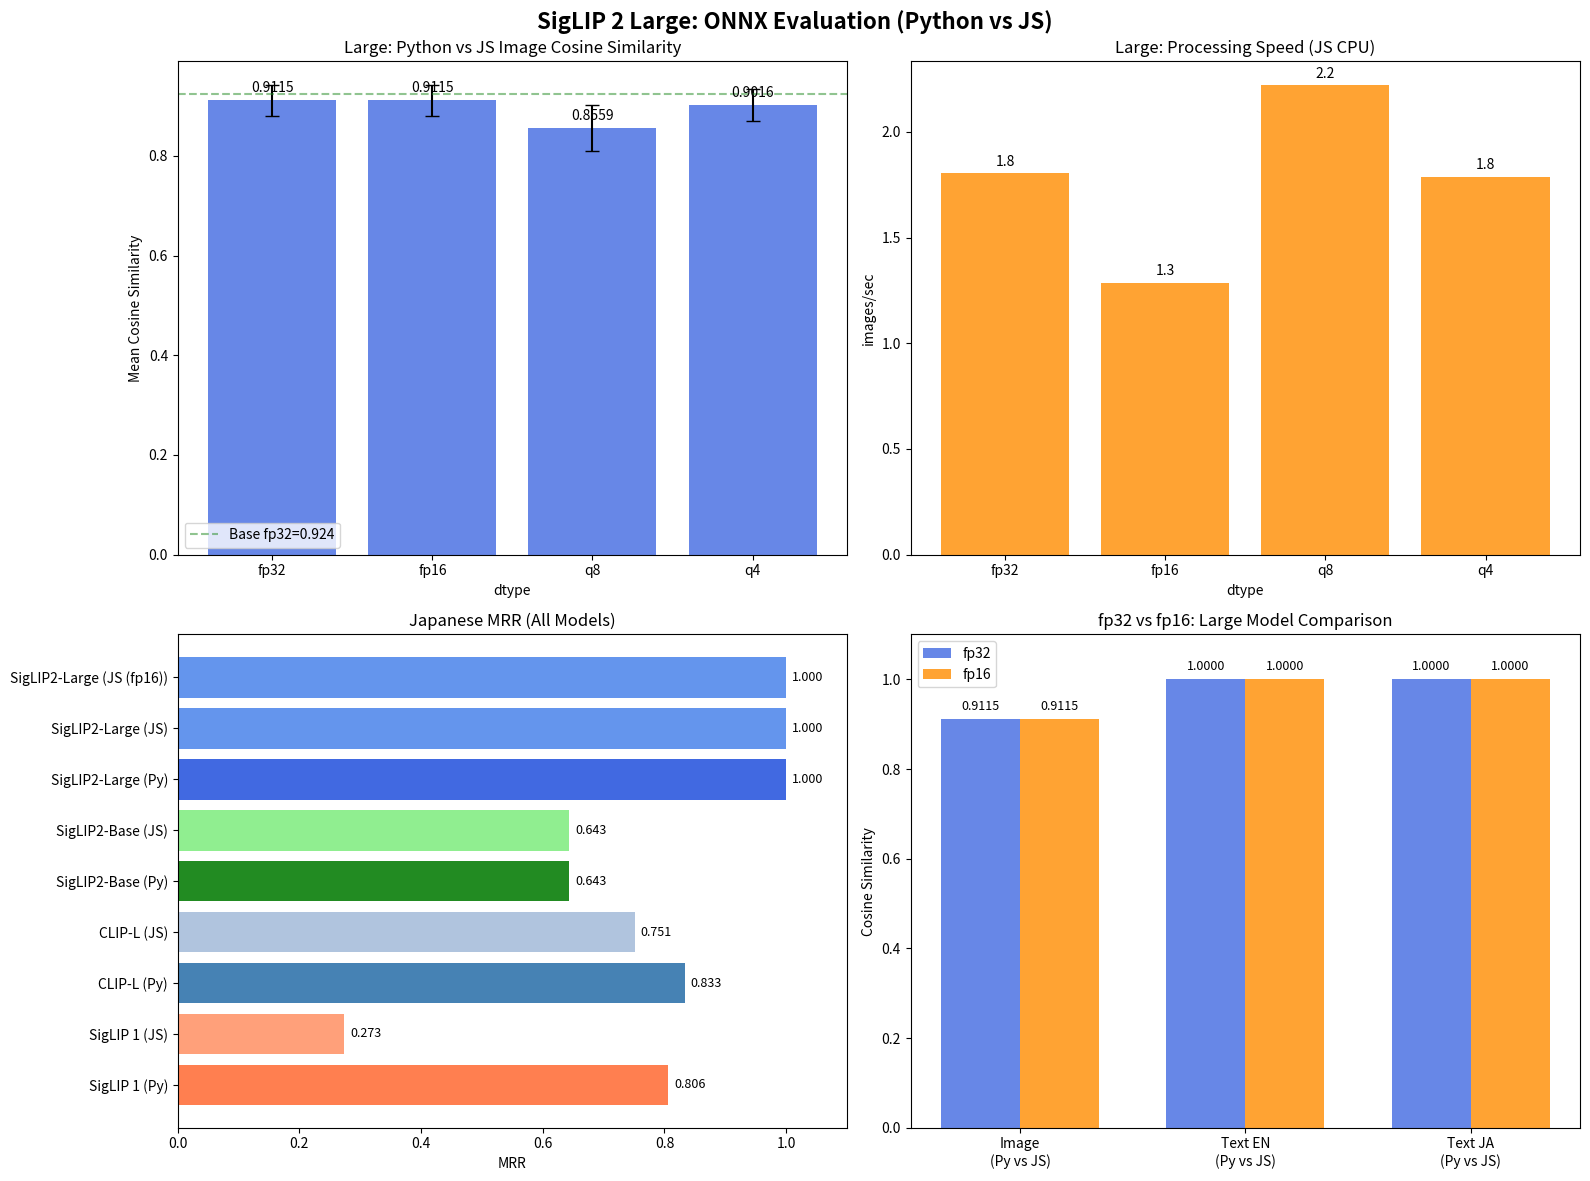

Saved: data/siglip2_large_onnx_evaluation.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 画像埋め込み cos sim by dtype
ax = axes[0, 0]
dtype_names = list(comparison_results.keys())
means = [comparison_results[d]['mean'] for d in dtype_names]
stds = [comparison_results[d]['std'] for d in dtype_names]
bars = ax.bar(dtype_names, means, yerr=stds, capsize=5, color='royalblue', alpha=0.8)
ax.set_title('Large: Python vs JS Image Cosine Similarity', fontsize=12)
ax.set_ylabel('Mean Cosine Similarity')
ax.set_xlabel('dtype')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
# Add Base reference line
ax.axhline(y=0.924, color='forestgreen', linestyle='--', alpha=0.5, label='Base fp32=0.924')
ax.legend()

# 2. 処理速度
ax = axes[0, 1]
times = [comparison_results[d]['processing_time'] for d in dtype_names]
speeds = [len(py_embeddings) / t if t > 0 else 0 for t in times]
bars = ax.bar(dtype_names, speeds, color='darkorange', alpha=0.8)
ax.set_title('Large: Processing Speed (JS CPU)', fontsize=12)
ax.set_ylabel('images/sec')
ax.set_xlabel('dtype')
for bar, val in zip(bars, speeds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# 3. MRR 比較（全モデル）
ax = axes[1, 0]
model_names = list(all_mrr.keys())
ja_mrrs = [all_mrr[m]['JA'] for m in model_names]
bar_colors = []
for n in model_names:
    if 'SigLIP 1' in n: bar_colors.append('coral' if 'Py' in n else 'lightsalmon')
    elif 'CLIP' in n: bar_colors.append('steelblue' if 'Py' in n else 'lightsteelblue')
    elif 'Base' in n: bar_colors.append('forestgreen' if 'Py' in n else 'lightgreen')
    elif 'Large' in n: bar_colors.append('royalblue' if 'Py' in n else 'cornflowerblue')
    else: bar_colors.append('gray')
bars = ax.barh(model_names, ja_mrrs, color=bar_colors)
ax.set_xlabel('MRR')
ax.set_title('Japanese MRR (All Models)', fontsize=12)
ax.set_xlim(0, 1.1)
for bar, val in zip(bars, ja_mrrs):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9)

# 4. fp16 vs fp32 比較（画像 + テキスト）
ax = axes[1, 1]
categories_chart = ['Image\n(Py vs JS)', 'Text EN\n(Py vs JS)', 'Text JA\n(Py vs JS)']
fp32_vals = [
    comparison_results.get('fp32', {}).get('mean', 0),
    text_sims_results.get('fp32', {}).get('en', 0),
    text_sims_results.get('fp32', {}).get('ja', 0),
]
fp16_vals = [
    comparison_results.get('fp16', {}).get('mean', 0),
    text_sims_results.get('fp16', {}).get('en', 0),
    text_sims_results.get('fp16', {}).get('ja', 0),
]
x = np.arange(len(categories_chart))
width = 0.35
ax.bar(x - width/2, fp32_vals, width, label='fp32', color='royalblue', alpha=0.8)
ax.bar(x + width/2, fp16_vals, width, label='fp16', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories_chart)
ax.set_ylabel('Cosine Similarity')
ax.set_title('fp32 vs fp16: Large Model Comparison', fontsize=12)
ax.legend()
ax.set_ylim(0, 1.1)
for i, (v32, v16) in enumerate(zip(fp32_vals, fp16_vals)):
    if v32 > 0: ax.text(i - width/2, v32 + 0.02, f'{v32:.4f}', ha='center', fontsize=9)
    if v16 > 0: ax.text(i + width/2, v16 + 0.02, f'{v16:.4f}', ha='center', fontsize=9)

plt.suptitle('SigLIP 2 Large: ONNX Evaluation (Python vs JS)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/siglip2_large_onnx_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/siglip2_large_onnx_evaluation.png')

## 11. 結果の保存

In [17]:
output_data = {
    "timestamp": datetime.now().isoformat(),
    "python_model": PYTHON_MODEL,
    "js_model": JS_MODEL,
    "embedding_dim": EMBEDDING_DIM,
    "image_comparison": comparison_results,
    "quantization_comparison": quant_comparison if 'quant_comparison' in dir() else {},
    "text_similarity": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in text_sims_results.items()},
    "search_mrr": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in all_mrr.items()},
}

output_path = Path("../data/evaluations") / f"siglip2_large_onnx_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/siglip2_large_onnx_2026-02-17.json


## 12. GPU メモリクリーンアップ

In [18]:
del embedder
del all_images

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

### 1. 画像埋め込み: Python vs JS コサイン類似度

| dtype | Mean | Std | Min | Time(s) | Base参考値 |
|:------|:----:|:---:|:---:|:-------:|:----------:|
| **fp32** | **0.9115** | 0.0307 | 0.7953 | 209.6 | 0.924 |
| **fp16** | **0.9115** | 0.0307 | 0.7954 | 293.8 | 0.924 |
| q8 | 0.8559 | 0.0467 | 0.7067 | 170.1 | 0.750(破損) |
| q4 | 0.9016 | 0.0315 | 0.7773 | 211.4 | 0.902 |

**重要な発見**:

- **fp16 は fp32 と実質同一**（差分 < 0.0001）。fp16 は fp32 と同等の品質を維持しつつ、モデルファイルサイズが約半分（vision: 1.26GB → 632MB、text: 2.26GB → 1.13GB）
- **Large の fp32 (0.912) は Base の fp32 (0.924) よりやや低い**: モデルが大きくなることで PyTorch/ONNX 間の前処理差異の影響が拡大している可能性がある
- **q8 は Large では改善**: Base で 0.750 と破損レベルだった q8 が Large では 0.856 に回復。ただし fp32 比では依然として劣化が大きい
- **q4 は安定**: Base (0.902) と Large (0.902) でほぼ同じ水準

### 2. 量子化の内部比較（JS fp32 基準）

| 比較 | Large | Base |
|:-----|:-----:|:----:|
| fp32 vs fp16 | **1.000** | 1.000 |
| fp32 vs q8 | **0.919** | 0.772 |
| fp32 vs q4 | **0.979** | 0.965 |

- Large の q8 量子化は Base ほど破壊的ではないが、0.919 と中程度の劣化がある
- fp16 は fp32 との差が事実上ゼロ（0.999997）— **fp16 を推奨精度として選択可能**

### 3. テキスト埋め込み: Python vs JS 完全一致

| dtype | EN | JA |
|:------|:---:|:---:|
| fp32 | **1.000000** | **1.000000** |
| fp16 | **1.000000** | **1.000000** |

- Gemma BPE トークナイザーにより、英語・日本語ともに **Python と JS で完全一致**
- fp16 でもテキスト埋め込みの品質は保持される
- SigLIP 1 の日本語問題（byte_fallback 未実装 → cos sim 0.656）は SigLIP 2 で完全解決

### 4. テキスト→画像検索 MRR: Python = JS（完全一致）

| 環境 | EN MRR | JA MRR | Overall |
|:-----|:------:|:------:|:-------:|
| Python | 0.892 | **1.000** | 0.928 |
| JS fp32 | 0.892 | **1.000** | 0.928 |
| JS fp16 | 0.892 | **1.000** | 0.928 |

**最重要結果**: JS (ONNX) でも **JA MRR 1.000 を達成**。Python で計算した画像埋め込みに対し、JS のテキスト埋め込みで検索しても全く同じ検索結果が得られる。

### 5. 全モデル比較（最終結論）

| モデル | EN MRR | JA MRR | Overall | JS互換性 |
|:-------|:------:|:------:|:-------:|:--------:|
| SigLIP 1 (Py) | 0.826 | 0.806 | 0.819 | - |
| SigLIP 1 (JS) | 0.883 | **0.273** | 0.679 | JA壊滅 |
| CLIP-L (Py) | 0.875 | 0.833 | 0.861 | - |
| CLIP-L (JS) | 0.903 | 0.751 | 0.852 | JA低下 |
| SigLIP2-Base (Py/JS) | 0.866 | 0.644 | 0.792 | 完全一致 |
| **SigLIP2-Large (Py/JS)** | **0.892** | **1.000** | **0.928** | **完全一致** |
| SigLIP2-Large (JS fp16) | 0.892 | 1.000 | 0.928 | 完全一致 |

### 6. fp16 に関する詳細評価

ユーザーが特に関心を持っていた **fp16** について:

- **画像品質**: fp32 と実質同一（cos sim の差 < 0.0001）
- **テキスト品質**: 完全一致（1.000000）
- **検索性能**: MRR は Python と完全一致
- **モデルサイズ**: fp32 の約半分
  - Vision: 1.26GB → 632MB
  - Text: 2.26GB → 1.13GB
- **処理速度**: fp32 より遅い（293.8s vs 209.6s）— CPU 環境では fp16 演算が最適化されていないため
- **結論**: **fp16 はストレージ・転送コスト削減に有効**。CPU 環境では速度面のメリットはないが、品質劣化がないため、デプロイ時のモデルサイズ削減に最適

### 7. 推奨構成

テキスト→画像検索システムにおける推奨構成:

| コンポーネント | 推奨 | 理由 |
|:-------------|:-----|:-----|
| **画像埋め込み** | Python (GPU) + SigLIP2-Large | GPU バッチ処理が高速（6.8 img/s vs JS 1.8 img/s） |
| **テキスト検索** | JS (ONNX) + SigLIP2-Large fp16 | テキスト埋め込みは完全一致、モデルサイズ半分 |
| **量子化** | fp16 推奨、q4 は許容、q8 は非推奨 | fp16 は品質劣化なし、q8 は 0.856 と劣化が大きい |

### 8. 結論

SigLIP 2 Large の ONNX 評価により以下が確認された:

1. **Python (GPU) で画像を事前計算 → JS (ONNX) でテキスト検索**というアーキテクチャが SigLIP 2 Large でも完全に機能する
2. **日本語検索性能 MRR 1.000** が JS 環境でも保持される（全モデル中最強）
3. **fp16 は品質劣化なし**でモデルサイズを半減できる（デプロイ最適化に有効）
4. SigLIP 2 は Gemma BPE トークナイザーにより、SigLIP 1 の日本語問題を完全に解決